# Edge Detection Techniques and Their Impact on Classification Performance
### Lab 03: Comparative Edge Detection, Noise Robustness, Canny Tuning, and Raw vs. Filtered vs. Edge Classification

This notebook implements Lab Activity 3 in full, building directly on Lab 1 (backbone comparison) and Lab 2 (filter comparison), on the same ISIC 2019 5-class subset.

| # | Task | What it produces |
|---|---|---|
| Task 1 | Comparative Edge Detection | Sobel (Gx/Gy/magnitude), Prewitt, Laplacian, LoG, Canny on sample images from all 5 classes, plus the required Original to Sobel to Prewitt to Laplacian to LoG to Canny figure |
| Task 2 | Effect of Noise on Edge Detection | Gaussian and salt-and-pepper noise, with and without Gaussian/Median denoising, run through the edge detectors; **Table 1** |
| Task 3 | Canny Parameter Analysis | 3 threshold combinations + a kernel-size variant; **Table 2**; picks the single best edge detector overall (used as Set C below) |
| Task 4/5 | Classification Using Edge Maps | Fresh, identical-condition training on Raw (Set A), Filtered (Set B), and Edge (Set C) images, for SVM/Random Forest/KNN (on deep features) and 2 CNN backbones; **Table 3** |
| Task 6 | Visual Comparison | Confusion matrices and a metric bar chart for the best-performing model across all 3 conditions |

**Stated assumptions (change the flagged config variables if you want something different):**

- **CNN Model 1 / CNN Model 2** (Table 3's two CNN rows): **ResNet50** and **EfficientNet-B0**, the top 2 of Lab 1/2's top 3 by Lab 1 accuracy (81.19%, 81.08%; DenseNet121 was 3rd at 80.95%). These two also agree that Sharpening was their best Lab 2 filter, so Set B below has one clean answer instead of splitting between Sharpening and DenseNet121's Gaussian. See `CNN_MODELS` in Setup.
- **Set B's filter**: **Sharpening**, the only Lab 2 filter that improved both of the chosen models (ResNet50 +0.47, EfficientNet-B0 +3.55 percentage points accuracy). See `BEST_FILTER` in Setup.
- **Set C's edge method**: chosen automatically, from real numbers computed in Tasks 1 to 3 (a density + continuity quality score on clean images, informed by the noise-robustness results where available). Canny is the theoretically favored candidate (non-maximum suppression and hysteresis thresholding are designed to produce thin, continuous edges, unlike a raw gradient-magnitude map), but the notebook does not hardcode that; see `BEST_EDGE_METHOD_OVERRIDE` in Task 3 if you want to force a specific method after reviewing the real results.
- **Table 3, fresh retraining rather than reused Lab 1/2 numbers**: Task 4 of the brief explicitly asks to train and evaluate on Raw, Filtered, and Edge "using the same training set / validation set / test set / number of epochs / evaluation metrics ... to ensure a fair comparison." Lab 1 used a 2+6 epoch schedule and Lab 2 used 1+4, so their old numbers are not directly comparable to each other or to a new Edge condition. This notebook instead retrains all 5 rows (SVM, Random Forest, KNN, ResNet50, EfficientNet-B0) on all 3 conditions, fresh, under identical settings, so Table 3 is an apples-to-apples comparison. The brief's own narrower template (`Accuracy Raw (Lab 1)` / `Accuracy Filtered (Lab 2)` / `Accuracy Edge (Lab 3)` as three columns, one shared Precision/Recall/F1/time set) is also produced, using the Edge condition for the single-valued columns since that is this lab's own new contribution; the full long-format table with every metric for all 3 conditions is saved alongside it.
- **Epoch budget**: 1 warmup + 4 fine-tune epochs per CNN run, matching Lab 2 (your choice). 2 CNN models x 3 conditions = 6 end-to-end training runs; deep-feature extraction for the classifiers is a forward pass only (no training) and runs 3 times (once per condition), shared across SVM/Random Forest/KNN.

**Crash-resilience**: same pattern as Lab 2. Every (row, condition) result is checkpointed to CSV/JSON immediately after it finishes, and by default this is saved to **your Google Drive** rather than the Colab VM's local disk, so a full runtime reset can resume instead of restarting from zero. ResNet50's fine-tuned weights are also saved per condition (also to Drive), since the classical classifiers need to reuse that exact fine-tuned network as their deep-feature extractor, matching how Lab 1's classical classifiers used the fine-tuned backbone's features rather than a generic frozen ImageNet one. Set `CONFIG["save_to_drive"] = False` to opt out and accept that a full reset loses progress.

Run top to bottom in Google Colab with a GPU runtime (`Runtime -> Change runtime type -> GPU`).


## 2. Setup

In [1]:
# Packages not preinstalled on Colab (safe to re-run)
!pip install -q kagglehub --upgrade


In [2]:
import os, glob, time, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as tvm
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
RESAMPLE_BILINEAR = getattr(getattr(Image, "Resampling", Image), "BILINEAR")  # Pillow-version-safe

try:
    import cv2
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "opencv-python-headless"], check=True)
    import cv2

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    precision_recall_fscore_support, roc_auc_score, roc_curve,
    balanced_accuracy_score, confusion_matrix,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

CONFIG = {
    "seed": SEED,
    "img_size": 224,
    "batch_size": 64,
    "num_workers": min(4, os.cpu_count() or 2),
    "selected_classes": ["MEL", "NV", "BCC", "BKL", "AK"],  # same 5 classes as Lab 1 and Lab 2
    "epochs_warmup": 1,     # phase 1: backbone frozen, train only the new head (Lab 2's schedule)
    "epochs_finetune": 4,   # phase 2: backbone unfrozen, fine-tune the whole network
    "lr_warmup": 1e-3,
    "lr_finetune": 1e-4,
    "val_size": 0.15,
    "test_size": 0.15,
    "cache_images_in_ram": True,
    "save_to_drive": True,  # persist checkpoints (and ResNet50 weights) in Google Drive
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}
print("Using device:", CONFIG["device"])
if CONFIG["device"] == "cpu":
    print("WARNING: no GPU detected. The 6 CNN training runs on CPU will be extremely slow, "
          "in Colab go to Runtime > Change runtime type > GPU.")

# Stated assumption: CNN Model 1 / CNN Model 2 in Table 3 = the top 2 of Lab 1's top 3 by accuracy
CNN_MODELS = ["resnet50", "efficientnet_b0"]
MODEL_DISPLAY = {"resnet50": "ResNet50", "efficientnet_b0": "EfficientNet-B0", "densenet121": "DenseNet121"}

# Stated assumption: Set B's filter (both chosen models' best Lab 2 filter)
BEST_FILTER = "sharpen"

CLASSIFIERS = ["svm", "random_forest", "knn"]
CLASSIFIER_DISPLAY = {"svm": "SVM", "random_forest": "Random Forest", "knn": "KNN"}
SVM_SUBSAMPLE_SIZE = 6000  # same tractability subsample Lab 1 used for SVM

CONDITIONS = ["raw", "filtered", "edge"]
CONDITION_DISPLAY = {"raw": "Raw", "filtered": "Filtered", "edge": "Edge"}

# Checkpoints (RESULTS_CSV/EXTRAS_JSON) and ResNet50's fine-tuned weights live on Google Drive
# by default, so the training sweep in Task 4/5 can resume after a FULL runtime reset. The first
# mount on a fresh runtime pops a one-time Google auth prompt in the UI, click through it.
RESULTS_DIR = "/content/lab03_results"  # local fallback if Drive isn't used/available
if CONFIG["save_to_drive"]:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        RESULTS_DIR = "/content/drive/MyDrive/Lab03_ISIC_EdgeDetection"
    except ImportError:
        print("google.colab not available (not running in Colab?), falling back to local, "
              "non-persistent storage. A full runtime reset will lose all progress.")
os.makedirs(RESULTS_DIR, exist_ok=True)
RESULTS_CSV = f"{RESULTS_DIR}/results.csv"
EXTRAS_JSON = f"{RESULTS_DIR}/extras.json"
persisted = RESULTS_DIR.startswith("/content/drive/")
print("Checkpointing to:", RESULTS_DIR, "(Drive: survives a full runtime reset)" if persisted
      else "(LOCAL ONLY: a full runtime reset will lose all completed runs)")

CONFIG


Using device: cuda
Mounted at /content/drive
Checkpointing to: /content/drive/MyDrive/Lab03_ISIC_EdgeDetection (Drive: survives a full runtime reset)


{'seed': 42,
 'img_size': 224,
 'batch_size': 64,
 'num_workers': 2,
 'selected_classes': ['MEL', 'NV', 'BCC', 'BKL', 'AK'],
 'epochs_warmup': 1,
 'epochs_finetune': 4,
 'lr_warmup': 0.001,
 'lr_finetune': 0.0001,
 'val_size': 0.15,
 'test_size': 0.15,
 'cache_images_in_ram': True,
 'save_to_drive': True,
 'device': 'cuda'}

## 3. Dataset Preparation

Same dataset, same 5-class filter, same stratified 70/15/15 split (same seed) and same in-RAM image caching as Lab 1 and Lab 2, so all three labs' results stay comparable.


In [3]:
import kagglehub

DATA_DIR = kagglehub.dataset_download("salviohexia/isic-2019-skin-lesion-images-for-classification")
print("Path to dataset files:", DATA_DIR)

print("\nTop-level contents of", DATA_DIR)
for root, dirs, fnames in os.walk(DATA_DIR):
    depth = root[len(DATA_DIR):].count(os.sep)
    if depth <= 1:
        print(root, "->", dirs[:10], f"(+{len(fnames)} files)" if fnames else "")


100%|██████████| 9.10G/9.10G [04:19<00:00, 37.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1

Top-level contents of /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1 -> ['VASC', 'MEL', 'SCC', 'BKL', 'DF', 'BCC', 'AK', 'NV'] (+2 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/VASC -> [] (+253 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/MEL -> [] (+4522 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/SCC -> [] (+628 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/BKL -> [] (+2624 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-ima

In [4]:
# Auto-detect the ground-truth CSV and index every image by filename (this dataset
# stores images inside per-class subfolders, not one flat folder).
csv_candidates = [p for p in glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)
                   if "ground" in p.lower() or "groundtruth" in p.lower()]
print("Ground-truth CSV candidates found:", csv_candidates)
GT_CSV_PATH = csv_candidates[0] if csv_candidates else None  # set manually if this is wrong

image_paths = (
    glob.glob(f"{DATA_DIR}/**/*.jpg", recursive=True)
    + glob.glob(f"{DATA_DIR}/**/*.jpeg", recursive=True)
    + glob.glob(f"{DATA_DIR}/**/*.png", recursive=True)
)
image_folders = sorted({os.path.dirname(p) for p in image_paths})
IMAGE_INDEX = {os.path.splitext(os.path.basename(p))[0]: p for p in image_paths}

print(f"Indexed {len(IMAGE_INDEX)} images across {len(image_folders)} folder(s):")
for f in image_folders:
    print(" ", f, f"({len(glob.glob(f'{f}/*.*'))} files)")

print("\nUsing GT_CSV_PATH =", GT_CSV_PATH)
assert GT_CSV_PATH, "Could not auto-detect the ground-truth CSV (set GT_CSV_PATH manually above)."
assert len(IMAGE_INDEX) > 0, "Could not find any images under DATA_DIR (check the download)."


Ground-truth CSV candidates found: ['/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/ISIC_2019_Training_GroundTruth.csv']
Indexed 25331 images across 8 folder(s):
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/AK (867 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/BCC (3323 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/BKL (2624 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/DF (239 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/MEL (4522 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/NV (12875 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-201

Filtered to ['MEL', 'NV', 'BCC', 'BKL', 'AK'] -> kept 24211/25331 images

Class distribution:
label
NV     12875
MEL     4522
BCC     3323
BKL     2624
AK       867
Name: count, dtype: int64

Classes: ['AK', 'BCC', 'BKL', 'MEL', 'NV']  | NUM_CLASSES = 5


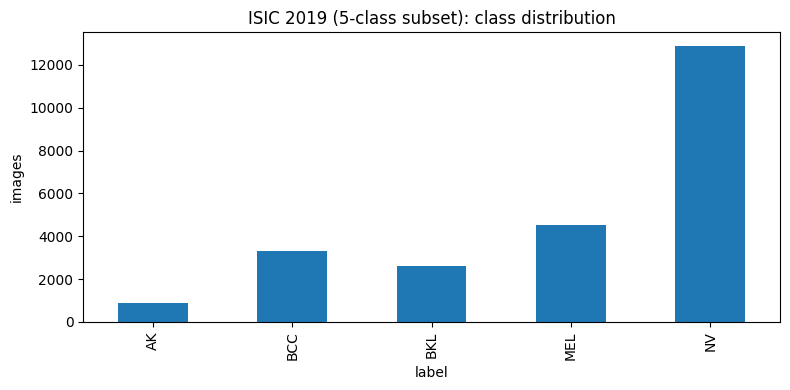

In [5]:
gt = pd.read_csv(GT_CSV_PATH)
class_cols = [c for c in gt.columns if c.lower() != "image"]
if "UNK" in gt.columns and gt["UNK"].sum() == 0:
    class_cols = [c for c in class_cols if c != "UNK"]

gt["label"] = gt[class_cols].idxmax(axis=1)
gt["filepath"] = gt["image"].map(IMAGE_INDEX)

n_missing = gt["filepath"].isna().sum()
if n_missing:
    print(f"Warning: {n_missing} images listed in the CSV were not found on disk, dropping them.")
gt = gt.dropna(subset=["filepath"]).reset_index(drop=True)

before = len(gt)
gt = gt[gt["label"].isin(CONFIG["selected_classes"])].reset_index(drop=True)
print(f"Filtered to {CONFIG['selected_classes']} -> kept {len(gt)}/{before} images")

print("\nClass distribution:")
print(gt["label"].value_counts())

CLASSES = sorted(gt["label"].unique().tolist())
label2idx = {c: i for i, c in enumerate(CLASSES)}
gt["label_idx"] = gt["label"].map(label2idx)
NUM_CLASSES = len(CLASSES)
print("\nClasses:", CLASSES, " | NUM_CLASSES =", NUM_CLASSES)

ax = gt["label"].value_counts().reindex(CLASSES).plot(kind="bar", figsize=(8, 4), title="ISIC 2019 (5-class subset): class distribution")
ax.set_ylabel("images"); plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/class_distribution.png", dpi=120); plt.show()


In [6]:
train_df, temp_df = train_test_split(
    gt, test_size=CONFIG["val_size"] + CONFIG["test_size"],
    stratify=gt["label_idx"], random_state=CONFIG["seed"]
)
val_fraction_of_temp = CONFIG["val_size"] / (CONFIG["val_size"] + CONFIG["test_size"])
val_df, test_df = train_test_split(
    temp_df, train_size=val_fraction_of_temp,
    stratify=temp_df["label_idx"], random_state=CONFIG["seed"]
)
train_df, val_df, test_df = (d.reset_index(drop=True) for d in (train_df, val_df, test_df))
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")


train=16947  val=3632  test=3632


In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Cache the RESIZED, UNPROCESSED pixel arrays once (same fix as Lab 1/2). Conditions (raw,
# filtered, edge) are applied on the fly per item, cheap relative to the JPEG decode/resize
# this cache already eliminates, and this avoids caching 3 processed copies of the dataset.
IMAGE_CACHE = {}
if CONFIG["cache_images_in_ram"]:
    def load_resized(path, size):
        with Image.open(path) as im:
            return np.asarray(im.convert("RGB").resize((size, size), RESAMPLE_BILINEAR), dtype=np.uint8)

    used_paths = pd.concat([train_df, val_df, test_df])["filepath"].unique()
    est_gb = len(used_paths) * (CONFIG["img_size"] ** 2) * 3 / 1e9
    print(f"Caching {len(used_paths)} images at {CONFIG['img_size']}x{CONFIG['img_size']} (~{est_gb:.2f} GB in RAM)...")
    t0 = time.time()
    for i, p in enumerate(used_paths):
        IMAGE_CACHE[p] = load_resized(p, CONFIG["img_size"])
        if (i + 1) % 5000 == 0:
            print(f"  cached {i+1}/{len(used_paths)}  ({(time.time()-t0)/60:.1f} min elapsed)")
    print(f"Done caching {len(IMAGE_CACHE)} images in {(time.time()-t0)/60:.1f} min.")

class_weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=train_df["label_idx"].values)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(CONFIG["device"])
print("Class weights:", dict(zip(CLASSES, class_weights.round(2))))

# One representative image per class, used throughout Tasks 1-3 below.
SAMPLE_IMAGES = {}
_example_rows = gt.groupby("label").first().reindex(CLASSES)
for cls, row in _example_rows.iterrows():
    _fp = row["filepath"]
    if _fp in IMAGE_CACHE:
        SAMPLE_IMAGES[cls] = IMAGE_CACHE[_fp]
    else:
        SAMPLE_IMAGES[cls] = np.asarray(
            Image.open(_fp).convert("RGB").resize((CONFIG["img_size"], CONFIG["img_size"]), RESAMPLE_BILINEAR))
print("Sample images selected for Tasks 1-3:", {c: SAMPLE_IMAGES[c].shape for c in CLASSES})


Caching 24211 images at 224x224 (~3.64 GB in RAM)...
  cached 5000/24211  (1.4 min elapsed)
  cached 10000/24211  (2.8 min elapsed)
  cached 15000/24211  (4.2 min elapsed)
  cached 20000/24211  (5.6 min elapsed)
Done caching 24211 images in 6.8 min.
Class weights: {'AK': np.float64(5.58), 'BCC': np.float64(1.46), 'BKL': np.float64(1.85), 'MEL': np.float64(1.07), 'NV': np.float64(0.38)}
Sample images selected for Tasks 1-3: {'AK': (224, 224, 3), 'BCC': (224, 224, 3), 'BKL': (224, 224, 3), 'MEL': (224, 224, 3), 'NV': (224, 224, 3)}


## 4. Task 1: Comparative Edge Detection

Implements every method the brief lists: Sobel (Gx), Sobel (Gy), Sobel gradient magnitude, Prewitt, Laplacian, Laplacian of Gaussian (LoG), and Canny. These utility functions are reused unchanged in Tasks 2, 3, and the Set C edge condition in Task 4.


In [8]:
def to_gray(img_uint8):
    if img_uint8.ndim == 3:
        return cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    return img_uint8

def normalize_to_uint8(arr):
    return cv2.normalize(arr, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

DETECTOR_DISPLAY = {
    "sobel_gx": "Sobel (Gx)", "sobel_gy": "Sobel (Gy)", "sobel": "Sobel",
    "prewitt": "Prewitt", "laplacian": "Laplacian", "log": "LoG", "canny": "Canny",
}

def compute_edge_map(img_uint8, method, low=50, high=150, ksize=3):
    '''Returns a single-channel uint8 edge map (0-255) for any of the 7 methods above.
    `low`/`high`/`ksize` only matter for Canny (Task 3 sweeps these).'''
    gray = to_gray(img_uint8)
    if method == "sobel_gx":
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        return normalize_to_uint8(np.abs(gx))
    if method == "sobel_gy":
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        return normalize_to_uint8(np.abs(gy))
    if method == "sobel":
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        mag = np.sqrt(gx ** 2 + gy ** 2)
        return normalize_to_uint8(mag)
    if method == "prewitt":
        kx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float32)
        ky = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)
        px = cv2.filter2D(gray, cv2.CV_64F, kx)
        py = cv2.filter2D(gray, cv2.CV_64F, ky)
        mag = np.sqrt(px ** 2 + py ** 2)
        return normalize_to_uint8(mag)
    if method == "laplacian":
        lap = cv2.Laplacian(gray, cv2.CV_64F, ksize=3)
        return normalize_to_uint8(np.abs(lap))
    if method == "log":
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        lap = cv2.Laplacian(blurred, cv2.CV_64F, ksize=3)
        return normalize_to_uint8(np.abs(lap))
    if method == "canny":
        k = ksize if ksize % 2 == 1 else ksize + 1
        blurred = cv2.GaussianBlur(gray, (k, k), 0)  # Gaussian smoothing is conventionally part of the Canny pipeline
        return cv2.Canny(blurred, low, high)
    raise ValueError(f"Unknown edge detection method: {method}")

CANNY_DEFAULT = dict(low=50, high=150, ksize=3)  # used wherever Canny appears before Task 3's own tuning
edge_kwargs = lambda method: CANNY_DEFAULT if method == "canny" else {}

# Quick correctness check
_test_img = SAMPLE_IMAGES[CLASSES[0]]
for _m in DETECTOR_DISPLAY:
    _out = compute_edge_map(_test_img, _m, **edge_kwargs(_m))
    assert _out.shape == _test_img.shape[:2] and _out.dtype == np.uint8, f"method {_m} produced unexpected shape/dtype"
print("All 7 edge-detection methods produce a", _test_img.shape[:2], "uint8 map. OK.")


All 7 edge-detection methods produce a (224, 224) uint8 map. OK.


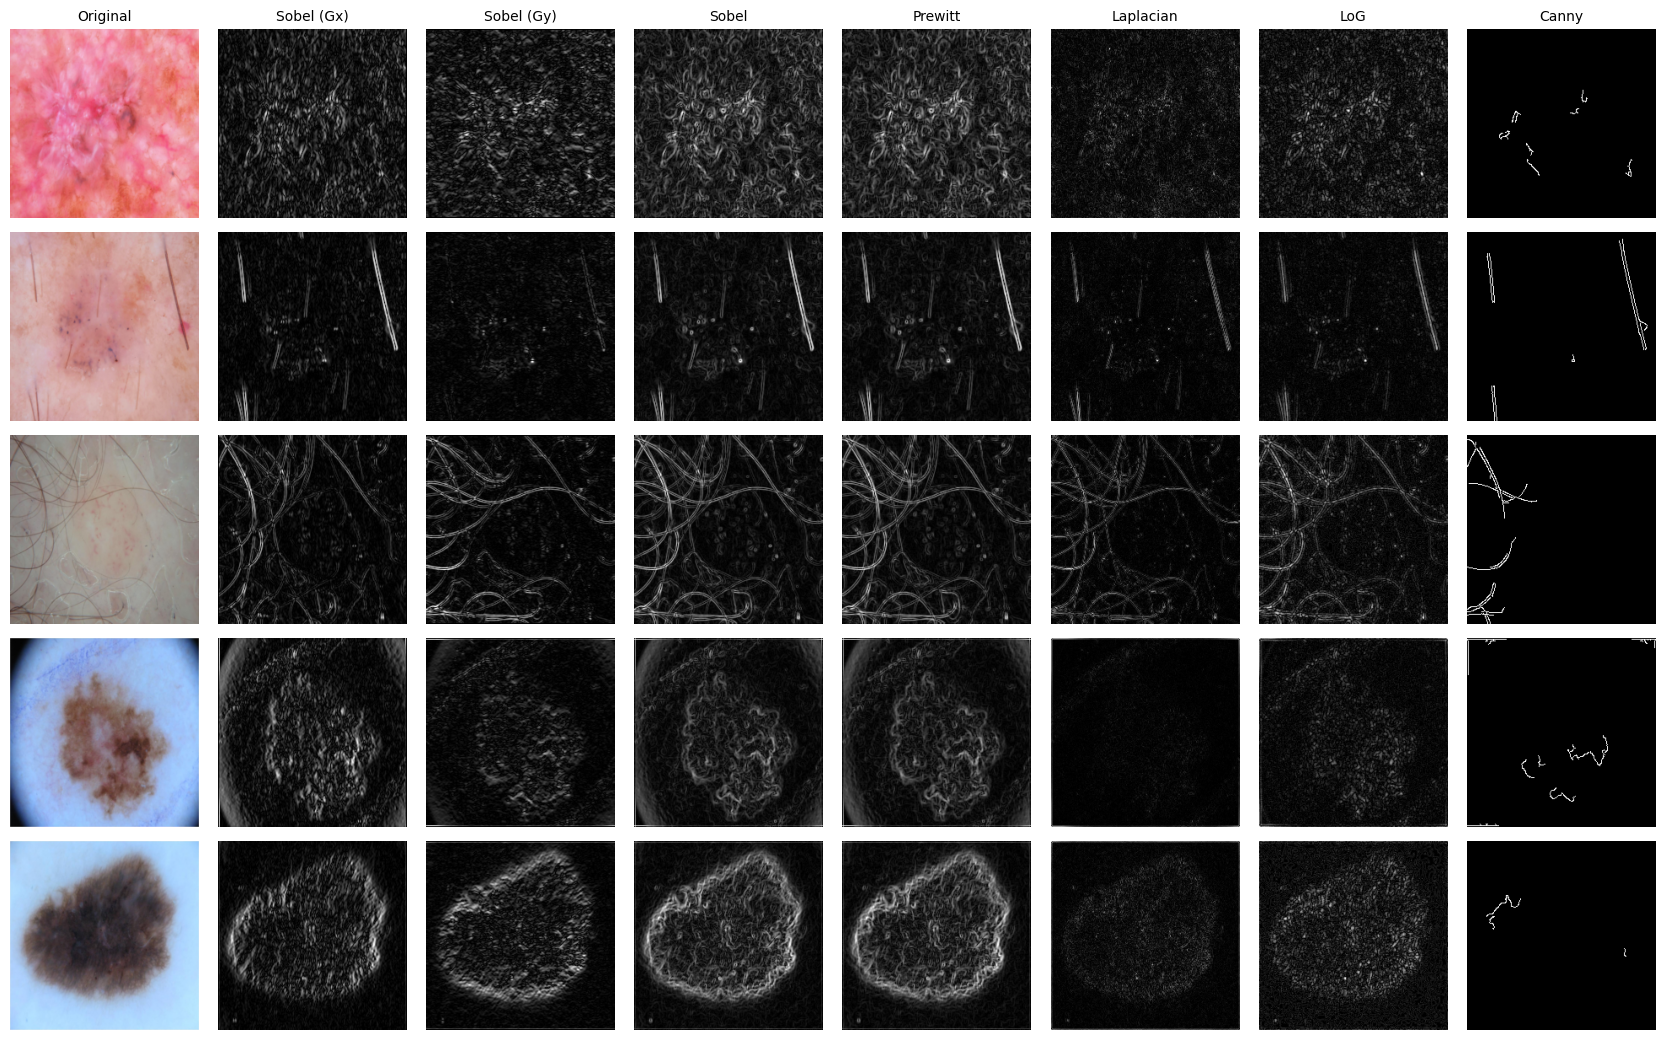

In [9]:
# Full method-by-method figure: Original + all 7 methods, for all 5 classes (>= the 3 required).
METHODS_FULL = ["sobel_gx", "sobel_gy", "sobel", "prewitt", "laplacian", "log", "canny"]

fig, axes = plt.subplots(len(CLASSES), 1 + len(METHODS_FULL), figsize=(2.1 * (1 + len(METHODS_FULL)), 2.1 * len(CLASSES)))
for i, cls in enumerate(CLASSES):
    img = SAMPLE_IMAGES[cls]
    axes[i, 0].imshow(img); axes[i, 0].axis("off")
    if i == 0:
        axes[i, 0].set_title("Original", fontsize=10)
    axes[i, 0].set_ylabel(cls, fontsize=10)
    for j, method in enumerate(METHODS_FULL, start=1):
        edge = compute_edge_map(img, method, **edge_kwargs(method))
        axes[i, j].imshow(edge, cmap="gray"); axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(DETECTOR_DISPLAY[method], fontsize=10)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task1_all_methods.png", dpi=120)
plt.show()


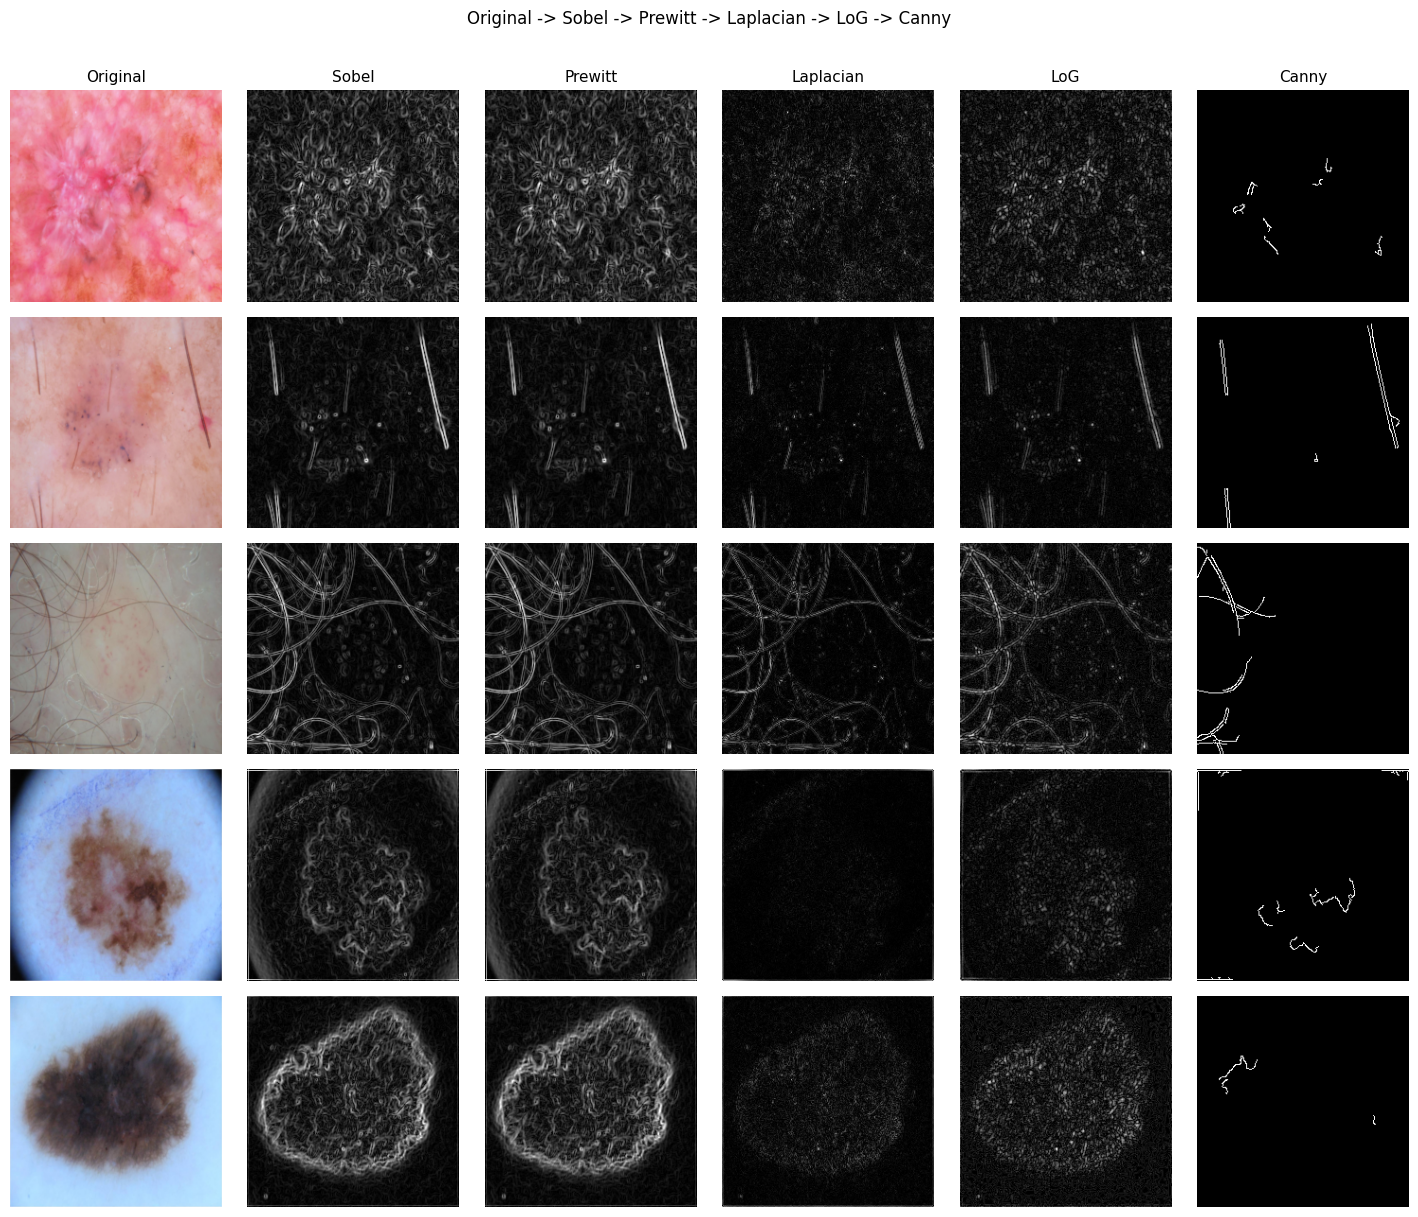

In [10]:
# Required figure: Original -> Sobel -> Prewitt -> Laplacian -> LoG -> Canny (Sobel = magnitude here).
METHODS_SUMMARY = ["sobel", "prewitt", "laplacian", "log", "canny"]

fig, axes = plt.subplots(len(CLASSES), 1 + len(METHODS_SUMMARY), figsize=(2.4 * (1 + len(METHODS_SUMMARY)), 2.4 * len(CLASSES)))
for i, cls in enumerate(CLASSES):
    img = SAMPLE_IMAGES[cls]
    axes[i, 0].imshow(img); axes[i, 0].axis("off")
    if i == 0:
        axes[i, 0].set_title("Original", fontsize=11)
    axes[i, 0].set_ylabel(cls, fontsize=11)
    for j, method in enumerate(METHODS_SUMMARY, start=1):
        edge = compute_edge_map(img, method, **edge_kwargs(method))
        axes[i, j].imshow(edge, cmap="gray"); axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(DETECTOR_DISPLAY[method], fontsize=11)
fig.suptitle("Original -> Sobel -> Prewitt -> Laplacian -> LoG -> Canny", y=1.01)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task1_required_figure.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Task 2: Effect of Noise on Edge Detection

Adds Gaussian noise and salt-and-pepper noise to the same 5 sample images, denoises with Gaussian and Median filtering, then measures how each edge detector's output changes versus its own clean-image result. Two real, computed metrics stand in for what would otherwise be a purely subjective judgement call:

- **Edge Quality (%)**: a density + continuity score (defined below) applied directly to the resulting edge map. Peaks when the edge map has a plausible amount of edge content (not empty, not overwhelmed by noise) arranged into long, connected strands rather than scattered speckle.
- **Noise Sensitivity (%)**: `100 - Dice similarity` between the row's (Otsu-binarized) edge map and the same detector's edge map on the *clean* image. 0% means identical to the clean result; higher means more disrupted by the noise/preprocessing in that row.

`Observations` is generated from those same two numbers rather than left blank, but is meant as a starting point to edit for the report, not a substitute for looking at the actual figures below.


In [11]:
GAUSSIAN_NOISE_SIGMA = 25       # on a 0-255 scale
SALT_PEPPER_AMOUNT = 0.03       # fraction of pixels flipped to black/white

def add_gaussian_noise(img_uint8, sigma, rng):
    noise = rng.normal(0, sigma, img_uint8.shape)
    return np.clip(img_uint8.astype(np.float64) + noise, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(img_uint8, amount, rng):
    out = img_uint8.copy()
    h, w = img_uint8.shape[:2]
    n_each = int(amount * h * w / 2)
    ys, xs = rng.integers(0, h, n_each), rng.integers(0, w, n_each)
    out[ys, xs] = 255
    yp, xp = rng.integers(0, h, n_each), rng.integers(0, w, n_each)
    out[yp, xp] = 0
    return out

def binarize_otsu(edge_map_uint8):
    _, b = cv2.threshold(edge_map_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return b

def edge_pixel_stats(bin_map):
    n_components, _ = cv2.connectedComponents(bin_map)
    n_components = max(n_components - 1, 0)  # subtract the background label
    edge_px = int((bin_map > 0).sum())
    density_pct = 100.0 * edge_px / bin_map.size
    return {"density_pct": density_pct, "n_components": n_components, "edge_pixels": edge_px}

def dice_similarity(bin_a, bin_b):
    a, b = (bin_a > 0), (bin_b > 0)
    total = a.sum() + b.sum()
    if total == 0:
        return 1.0
    return float(2 * np.logical_and(a, b).sum() / total)

def quality_score(bin_map, target_density=8.0, density_spread=6.0, fragmentation_k=40.0):
    '''Density term peaks at `target_density`% edge pixels (a plausible lesion-boundary amount);
    continuity term rewards fewer, longer connected components over many tiny fragments.'''
    stats = edge_pixel_stats(bin_map)
    density_term = np.exp(-((stats["density_pct"] - target_density) / density_spread) ** 2)
    continuity_term = stats["edge_pixels"] / (stats["edge_pixels"] + fragmentation_k * max(stats["n_components"], 1))
    return float(100 * density_term * continuity_term)

# Build the 5 image variants (clean / noisy / denoised) for every sample image, once.
rng_noise = np.random.default_rng(CONFIG["seed"])
IMAGE_VARIANTS = {}
for cls in CLASSES:
    clean = SAMPLE_IMAGES[cls]
    noisy_g = add_gaussian_noise(clean, GAUSSIAN_NOISE_SIGMA, rng_noise)
    noisy_sp = add_salt_pepper_noise(clean, SALT_PEPPER_AMOUNT, rng_noise)
    IMAGE_VARIANTS[cls] = {
        "clean": clean,
        "noisy_gaussian": noisy_g,
        "noisy_sp": noisy_sp,
        "denoised_g_from_gaussian": cv2.GaussianBlur(noisy_g, (5, 5), 0),
        "denoised_m_from_sp": cv2.medianBlur(noisy_sp, 5),
    }
print("Built 5 image variants (clean, 2 noisy, 2 denoised) for each of the", len(CLASSES), "classes.")


Built 5 image variants (clean, 2 noisy, 2 denoised) for each of the 5 classes.


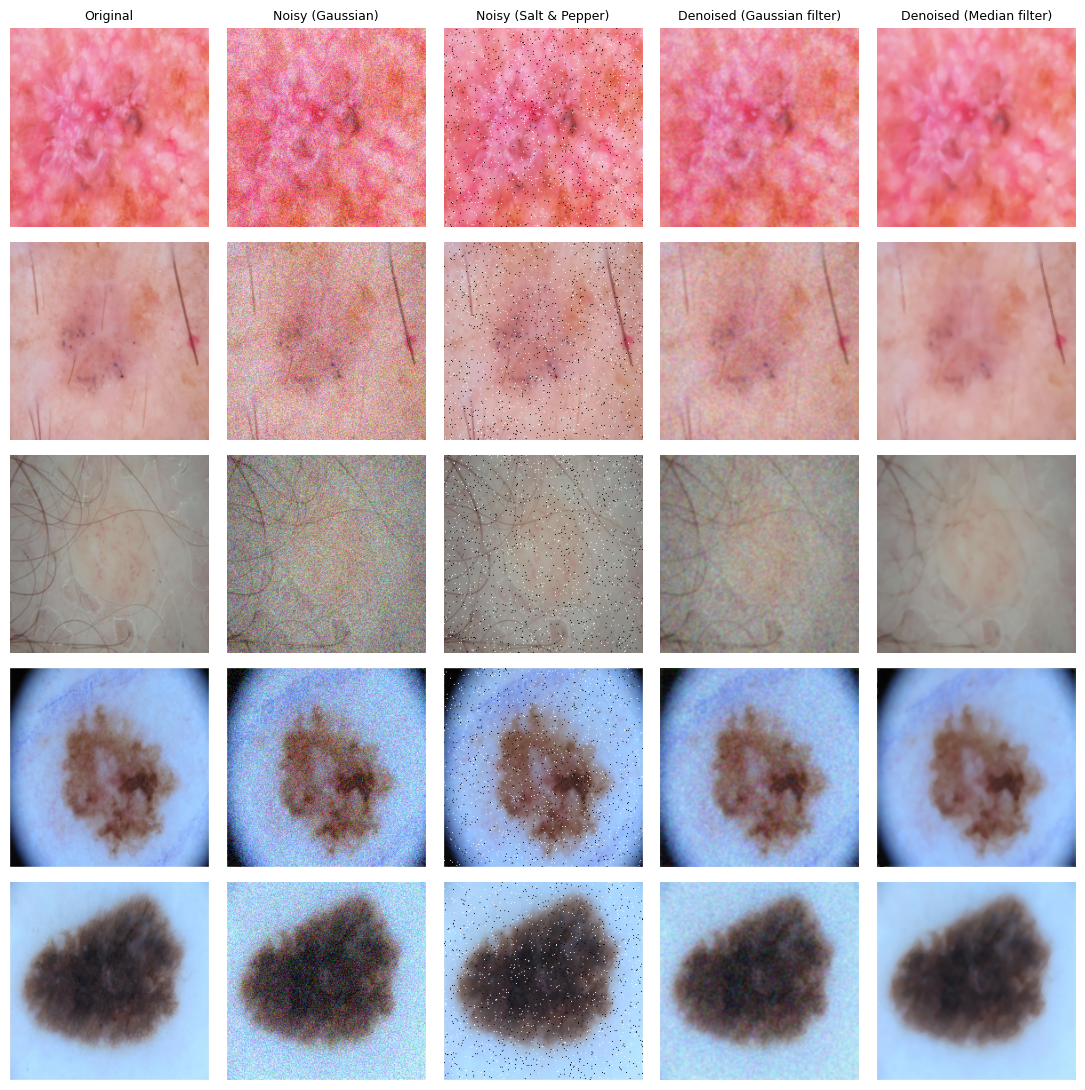

In [12]:
# Visualize the noise/denoising pipeline itself, before running any edge detector on it.
variant_order = ["clean", "noisy_gaussian", "noisy_sp", "denoised_g_from_gaussian", "denoised_m_from_sp"]
variant_titles = ["Original", "Noisy (Gaussian)", "Noisy (Salt & Pepper)", "Denoised (Gaussian filter)", "Denoised (Median filter)"]

fig, axes = plt.subplots(len(CLASSES), len(variant_order), figsize=(2.2 * len(variant_order), 2.2 * len(CLASSES)))
for i, cls in enumerate(CLASSES):
    for j, v in enumerate(variant_order):
        axes[i, j].imshow(IMAGE_VARIANTS[cls][v]); axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(variant_titles[j], fontsize=9)
        if j == 0:
            axes[i, j].set_ylabel(cls, fontsize=10)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task2_noise_examples.png", dpi=120)
plt.show()


In [13]:
def make_observation_from_avg(avg_dice, avg_quality):
    if avg_dice >= 0.95:
        sim_txt = "matches the clean-image edge map almost exactly"
    elif avg_dice >= 0.70:
        sim_txt = "stays close to the clean-image edge map"
    elif avg_dice >= 0.40:
        sim_txt = "moderately diverges from the clean-image edge map (some broken or shifted edges)"
    else:
        sim_txt = "diverges sharply from the clean-image edge map (heavy false or broken edges)"
    if avg_quality >= 40:
        qual_txt = "a well-formed, reasonably continuous edge map"
    elif avg_quality >= 15:
        qual_txt = "a moderately fragmented edge map"
    else:
        qual_txt = "a sparse or heavily fragmented edge map"
    return f"{sim_txt}, with {qual_txt}."

TABLE1_ROWS = [
    dict(detector="sobel", variant="clean", input_label="Original", noise_label="None", prep_label="None"),
    dict(detector="sobel", variant="noisy_gaussian", input_label="Noisy", noise_label="Gaussian", prep_label="None"),
    dict(detector="sobel", variant="noisy_sp", input_label="Noisy", noise_label="Salt & Pepper", prep_label="None"),
    dict(detector="sobel", variant="denoised_g_from_gaussian", input_label="Noisy", noise_label="Gaussian", prep_label="Gaussian Filter"),
    dict(detector="sobel", variant="denoised_m_from_sp", input_label="Noisy", noise_label="Salt & Pepper", prep_label="Median Filter"),
    dict(detector="prewitt", variant="clean", input_label="Original", noise_label="None", prep_label="None"),
    dict(detector="laplacian", variant="clean", input_label="Original", noise_label="None", prep_label="None"),
    dict(detector="log", variant="denoised_g_from_gaussian", input_label="Noisy", noise_label="Gaussian", prep_label="Gaussian Filter"),
    dict(detector="canny", variant="clean", input_label="Original", noise_label="None", prep_label="Built-in smoothing"),
    dict(detector="canny", variant="denoised_g_from_gaussian", input_label="Noisy", noise_label="Gaussian", prep_label="Gaussian Filter"),
    dict(detector="canny", variant="denoised_m_from_sp", input_label="Noisy", noise_label="Salt & Pepper", prep_label="Median Filter"),
]

def compute_table1_row(spec):
    dice_scores, qualities = [], []
    for cls in CLASSES:
        variants = IMAGE_VARIANTS[cls]
        img, clean_img = variants[spec["variant"]], variants["clean"]
        kwargs = edge_kwargs(spec["detector"])
        edge_map = compute_edge_map(img, spec["detector"], **kwargs)
        ref_map = compute_edge_map(clean_img, spec["detector"], **kwargs)
        bin_test, bin_ref = binarize_otsu(edge_map), binarize_otsu(ref_map)
        dice_scores.append(dice_similarity(bin_ref, bin_test))
        qualities.append(quality_score(bin_test))
    avg_dice, avg_quality = float(np.mean(dice_scores)), float(np.mean(qualities))
    return {
        "Edge Detector": DETECTOR_DISPLAY[spec["detector"]],
        "Input Image": spec["input_label"],
        "Noise Type": spec["noise_label"],
        "Preprocessing": spec["prep_label"],
        "Edge Quality (%)": round(avg_quality, 2),
        "Noise Sensitivity (%)": round((1 - avg_dice) * 100, 2),
        "Observations": make_observation_from_avg(avg_dice, avg_quality),
    }

table1_df = pd.DataFrame([compute_table1_row(spec) for spec in TABLE1_ROWS])
table1_df.to_csv(f"{RESULTS_DIR}/table1_noise_effect.csv", index=False)
table1_df


,Edge Detector,Input Image,Noise Type,Preprocessing,Edge Quality (%),Noise Sensitivity (%),Observations
0,Sobel,Original,None,None,6.09,0.00,matches the clean-image edge map almost exactl...
1,Sobel,Noisy,Gaussian,None,0.00,67.56,diverges sharply from the clean-image edge map...
2,Sobel,Noisy,Salt & Pepper,None,4.40,80.47,diverges sharply from the clean-image edge map...
3,Sobel,Noisy,Gaussian,Gaussian Filter,0.00,53.62,moderately diverges from the clean-image edge ...
4,Sobel,Noisy,Salt & Pepper,Median Filter,9.02,29.36,"stays close to the clean-image edge map, with ..."
5,Prewitt,Original,None,None,6.21,0.00,matches the clean-image edge map almost exactl...
6,Laplacian,Original,None,None,8.45,0.00,matches the clean-image edge map almost exactl...
7,LoG,Noisy,Gaussian,Gaussian Filter,0.00,68.05,diverges sharply from the clean-image edge map...
8,Canny,Original,None,Built-in smoothing,14.69,0.00,matches the clean-image edge map almost exactl...
9,Canny,Noisy,Gaussian,Gaussian Filter,9.46,77.13,diverges sharply from the clean-image edge map...


## 6. Task 3: Canny Parameter Analysis

Sweeps 3 threshold combinations plus a kernel-size variant (`Canny-4`, holding thresholds at `Canny-2`'s level so only the kernel size changes, standard one-variable-at-a-time practice). `Number of Detected Edges` counts foreground pixels in the Otsu-binarized edge map (the standard proxy, since individual edge curves are not uniquely well-defined), averaged across the 5 sample images. `Edge Quality (%)` is the same density + continuity score defined in Task 2.

The best-scoring configuration here is then compared against Sobel, Prewitt, Laplacian, and LoG (each on the same clean images) to pick **one overall best edge detection method**, used as Set C's condition in Task 4. See `BEST_EDGE_METHOD_OVERRIDE` below if you want to force a specific choice instead.


In [14]:
CANNY_CONFIGS = [
    dict(name="Canny-1", low=30, high=100, ksize=3),
    dict(name="Canny-2", low=50, high=150, ksize=3),
    dict(name="Canny-3", low=100, high=200, ksize=3),
    dict(name="Canny-4", low=50, high=150, ksize=5),  # kernel-size variant, thresholds held at Canny-2's level
]

def compute_table2_row(cfg):
    counts, qualities = [], []
    for cls in CLASSES:
        clean = IMAGE_VARIANTS[cls]["clean"]
        edge_map = compute_edge_map(clean, "canny", low=cfg["low"], high=cfg["high"], ksize=cfg["ksize"])
        bin_map = binarize_otsu(edge_map)
        stats = edge_pixel_stats(bin_map)
        counts.append(stats["edge_pixels"])
        qualities.append(quality_score(bin_map))
    avg_count, avg_quality = float(np.mean(counts)), float(np.mean(qualities))
    density_pct = avg_count / (CONFIG["img_size"] ** 2) * 100
    if density_pct > 15:
        obs = f"dense edge map ({density_pct:.1f}% of pixels), likely includes texture noise as false edges."
    elif density_pct < 2:
        obs = f"sparse edge map ({density_pct:.1f}% of pixels), may miss real lesion-boundary detail."
    else:
        obs = f"moderate edge density ({density_pct:.1f}% of pixels), a reasonable balance."
    return {
        "Configuration": cfg["name"], "Low Threshold": cfg["low"], "High Threshold": cfg["high"],
        "Kernel Size": f'{cfg["ksize"]}x{cfg["ksize"]}',
        "Edge Quality (%)": round(avg_quality, 2), "Number of Detected Edges": int(round(avg_count)),
        "Observation": obs,
    }

table2_df = pd.DataFrame([compute_table2_row(cfg) for cfg in CANNY_CONFIGS])
table2_df.to_csv(f"{RESULTS_DIR}/table2_canny_params.csv", index=False)

_best_idx = table2_df["Edge Quality (%)"].idxmax()
BEST_CANNY_CFG = CANNY_CONFIGS[_best_idx]
print(f"Best Canny configuration by Edge Quality: {table2_df.loc[_best_idx, 'Configuration']} "
      f"(low={BEST_CANNY_CFG['low']}, high={BEST_CANNY_CFG['high']}, ksize={BEST_CANNY_CFG['ksize']})")
table2_df


Best Canny configuration by Edge Quality: Canny-1 (low=30, high=100, ksize=3)


,Configuration,Low Threshold,High Threshold,Kernel Size,Edge Quality (%),Number of Detected Edges,Observation
0,Canny-1,30,100,3x3,38.98,1954,"moderate edge density (3.9% of pixels), a reas..."
1,Canny-2,50,150,3x3,14.69,406,"sparse edge map (0.8% of pixels), may miss rea..."
2,Canny-3,100,200,3x3,2.61,52,"sparse edge map (0.1% of pixels), may miss rea..."
3,Canny-4,50,150,5x5,7.85,115,"sparse edge map (0.2% of pixels), may miss rea..."


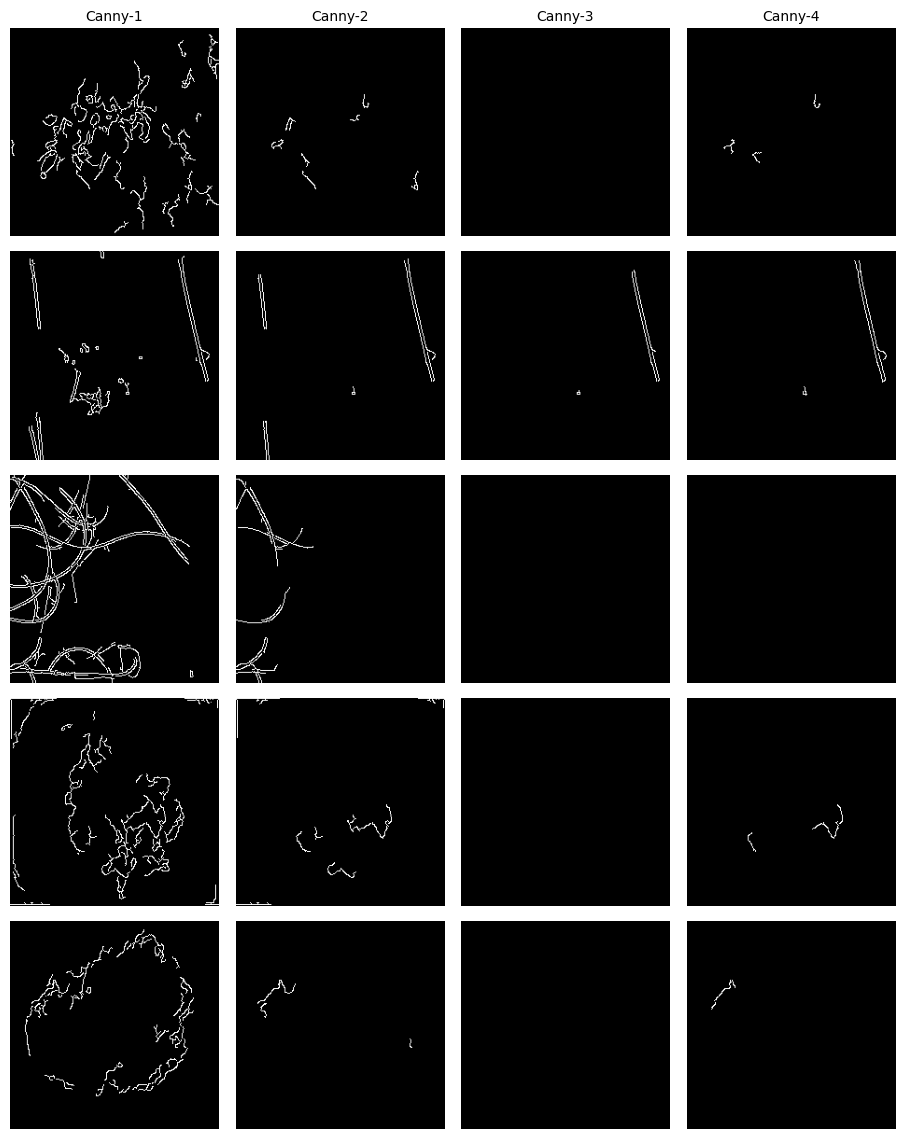

In [15]:
# Visualize the 4 Canny configurations side by side, for all 5 classes.
fig, axes = plt.subplots(len(CLASSES), len(CANNY_CONFIGS), figsize=(2.3 * len(CANNY_CONFIGS), 2.3 * len(CLASSES)))
for i, cls in enumerate(CLASSES):
    clean = IMAGE_VARIANTS[cls]["clean"]
    for j, cfg in enumerate(CANNY_CONFIGS):
        edge = compute_edge_map(clean, "canny", low=cfg["low"], high=cfg["high"], ksize=cfg["ksize"])
        axes[i, j].imshow(edge, cmap="gray"); axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(cfg["name"], fontsize=10)
        if j == 0:
            axes[i, j].set_ylabel(cls, fontsize=10)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task3_canny_params.png", dpi=120)
plt.show()


In [16]:
# Pick the single best edge detection method overall, from real computed numbers.
BEST_EDGE_METHOD_OVERRIDE = None  # e.g. set to "canny", "sobel", "prewitt", "laplacian", or "log" to force a choice

_candidate_methods = ["sobel", "prewitt", "laplacian", "log", "canny_best"]
_scores = {m: [] for m in _candidate_methods}
for cls in CLASSES:
    clean = IMAGE_VARIANTS[cls]["clean"]
    for method in ["sobel", "prewitt", "laplacian", "log"]:
        _scores[method].append(quality_score(binarize_otsu(compute_edge_map(clean, method))))
    _scores["canny_best"].append(quality_score(binarize_otsu(compute_edge_map(
        clean, "canny", low=BEST_CANNY_CFG["low"], high=BEST_CANNY_CFG["high"], ksize=BEST_CANNY_CFG["ksize"]))))
avg_scores = {m: float(np.mean(v)) for m, v in _scores.items()}

print("Average clean-image Edge Quality by candidate method (higher is better):")
for m, s in sorted(avg_scores.items(), key=lambda kv: -kv[1]):
    print(f"  {m:12s}: {s:.2f}")

# Noise-robustness context (only Sobel and Canny have thorough Table 1 coverage, shown for reference,
# not folded into the score above since Prewitt/Laplacian/LoG were not tested as thoroughly there).
_t1 = table1_df.set_index(["Edge Detector", "Input Image", "Noise Type"])
print("\nFor reference, Table 1's average Noise Sensitivity (%) for the two detectors tested most "
      "thoroughly under noise (lower is more robust):")
for det in ["Sobel", "Canny"]:
    vals = table1_df.loc[(table1_df["Edge Detector"] == det) & (table1_df["Noise Type"] != "None"), "Noise Sensitivity (%)"]
    if len(vals):
        print(f"  {det:8s}: {vals.mean():.2f}")

_winner_key = max(avg_scores, key=avg_scores.get)
_method_map = {"sobel": ("sobel", {}), "prewitt": ("prewitt", {}), "laplacian": ("laplacian", {}),
                "log": ("log", {}), "canny_best": ("canny", dict(low=BEST_CANNY_CFG["low"], high=BEST_CANNY_CFG["high"], ksize=BEST_CANNY_CFG["ksize"]))}

if BEST_EDGE_METHOD_OVERRIDE is not None:
    BEST_EDGE_METHOD = BEST_EDGE_METHOD_OVERRIDE
    BEST_EDGE_PARAMS = edge_kwargs(BEST_EDGE_METHOD) if BEST_EDGE_METHOD != "canny" else dict(
        low=BEST_CANNY_CFG["low"], high=BEST_CANNY_CFG["high"], ksize=BEST_CANNY_CFG["ksize"])
    print(f"\nBEST_EDGE_METHOD_OVERRIDE is set: forcing '{BEST_EDGE_METHOD}' instead of the computed winner.")
else:
    BEST_EDGE_METHOD, BEST_EDGE_PARAMS = _method_map[_winner_key]
    print(f"\n-> Automatically selected edge detection method for Set C: {DETECTOR_DISPLAY[BEST_EDGE_METHOD]} "
          f"({BEST_EDGE_PARAMS if BEST_EDGE_PARAMS else 'default params'})")


Average clean-image Edge Quality by candidate method (higher is better):
  canny_best  : 38.98
  laplacian   : 8.45
  prewitt     : 6.21
  sobel       : 6.09
  log         : 3.50

For reference, Table 1's average Noise Sensitivity (%) for the two detectors tested most thoroughly under noise (lower is more robust):
  Sobel   : 57.75
  Canny   : 73.95

-> Automatically selected edge detection method for Set C: Canny ({'low': 30, 'high': 100, 'ksize': 3})


## 7. Model Loading

Utilities shared by Task 4/5's training sweep: the same 2-phase warmup/fine-tune loop and evaluation routine Lab 1/2 used for the 2 CNN backbones, plus deep-feature extraction and the 3 classical classifiers (matching Lab 1's classifier configuration: Random Forest with 200 trees, KNN with k=5, RBF-SVM, SVM trained on a stratified subsample for tractability).


In [17]:
def get_head_module(model, name):
    if name == "resnet50":
        return model.fc
    if name == "densenet121":
        return model.classifier
    if name == "efficientnet_b0":
        return model.classifier[1]
    raise ValueError(name)

def build_model(name, num_classes, freeze_backbone=True):
    if name == "resnet50":
        model = tvm.resnet50(weights=tvm.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "densenet121":
        model = tvm.densenet121(weights=tvm.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif name == "efficientnet_b0":
        model = tvm.efficientnet_b0(weights=tvm.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model name: {name}")

    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
        for p in get_head_module(model, name).parameters():
            p.requires_grad = True
    return model

def train_one_phase(model, train_loader, val_loader, epochs, lr, class_weights, device, phase_label=""):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr)
    tag = f"[{phase_label}] " if phase_label else ""
    history = {"phase": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct_tr, n_tr = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            correct_tr += (outputs.argmax(1) == labels).sum().item()
            n_tr += imgs.size(0)
        train_loss, train_acc = running_loss / n_tr, correct_tr / n_tr

        model.eval()
        val_loss, correct_val, n_val = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                correct_val += (outputs.argmax(1) == labels).sum().item()
                n_val += imgs.size(0)
        val_loss, val_acc = val_loss / n_val, correct_val / n_val

        history["phase"].append(phase_label)
        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
        print(f"  {tag}epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
              f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

    return model, history

def train_warmup_finetune(model, train_loader, val_loader, config, class_weights, device):
    full_history = {"phase": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    if config["epochs_warmup"] > 0:
        model, h = train_one_phase(model, train_loader, val_loader, config["epochs_warmup"],
                                    config["lr_warmup"], class_weights, device, phase_label="warmup")
        for k in full_history: full_history[k].extend(h[k])
    if config["epochs_finetune"] > 0:
        for p in model.parameters():
            p.requires_grad = True
        model, h = train_one_phase(model, train_loader, val_loader, config["epochs_finetune"],
                                    config["lr_finetune"], class_weights, device, phase_label="finetune")
        for k in full_history: full_history[k].extend(h[k])
    return model, full_history

def evaluate_full(model, loader, num_classes, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            probs = torch.softmax(model(imgs), dim=1).cpu().numpy()
            all_preds.extend(probs.argmax(axis=1))
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)
    all_preds, all_labels, all_probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)

    acc = (all_preds == all_labels).mean()
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro", labels=np.arange(num_classes))
    except ValueError:
        auc = float("nan")

    pc_p, pc_r, pc_f1, pc_support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, zero_division=0, labels=np.arange(num_classes))
    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(num_classes))

    summary = {
        "Accuracy (%)": acc * 100, "Precision (%)": precision * 100, "Recall (%)": recall * 100,
        "F1-score (%)": f1 * 100, "Macro-F1 (%)": f1 * 100,
        "Balanced Accuracy (%)": bal_acc * 100, "AUC (%)": auc * 100,
    }
    per_class = {"precision": pc_p.tolist(), "recall": pc_r.tolist(), "f1": pc_f1.tolist(), "support": pc_support.tolist()}
    return summary, per_class, cm.tolist(), all_labels.tolist(), all_probs.tolist()

def time_ms(fn, n_repeats=30, n_warmup=5):
    '''Mean wall-clock time per call, in ms, after warmup. Same methodology Lab 1 used for its
    efficiency benchmark (30 timed runs after 5 warmup runs), applied here to both CNN forward
    passes and the classical classifiers' end-to-end (feature extraction + predict) latency.'''
    for _ in range(n_warmup):
        fn()
    if CONFIG["device"] == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n_repeats):
        fn()
    if CONFIG["device"] == "cuda":
        torch.cuda.synchronize()
    return (time.time() - t0) / n_repeats * 1000

CLASSIFIER_DEFS = {
    "svm": lambda: SVC(kernel="rbf", probability=True, random_state=SEED),
    "random_forest": lambda: RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    "knn": lambda: KNeighborsClassifier(n_neighbors=5),
}

def load_checkpoint():
    completed = set()
    if os.path.exists(RESULTS_CSV):
        prev = pd.read_csv(RESULTS_CSV)
        completed = set(zip(prev["Row"], prev["Condition"]))
    extras = {}
    if os.path.exists(EXTRAS_JSON):
        with open(EXTRAS_JSON) as f:
            extras = json.load(f)
    return completed, extras

def save_condition(row, key, extras, extra_payload):
    pd.DataFrame([row]).to_csv(RESULTS_CSV, mode="a", header=not os.path.exists(RESULTS_CSV), index=False)
    extras[key] = extra_payload
    with open(EXTRAS_JSON, "w") as f:
        json.dump(extras, f)


## 8. Task 4: Classification Using Edge Maps, Dataset Conditions

Builds the 3 dataset versions the brief asks for, applied on top of the shared `IMAGE_CACHE` exactly like Lab 2's filters were:

- **Set A, Raw**: the unprocessed cached image (identity).
- **Set B, Filtered**: `BEST_FILTER` (Sharpening, see the title cell for why).
- **Set C, Edge**: `BEST_EDGE_METHOD` with `BEST_EDGE_PARAMS`, as selected in Task 3, replicated to 3 channels so it fits the same model input pipeline (the same trick Lab 2 used for its Sobel filter).


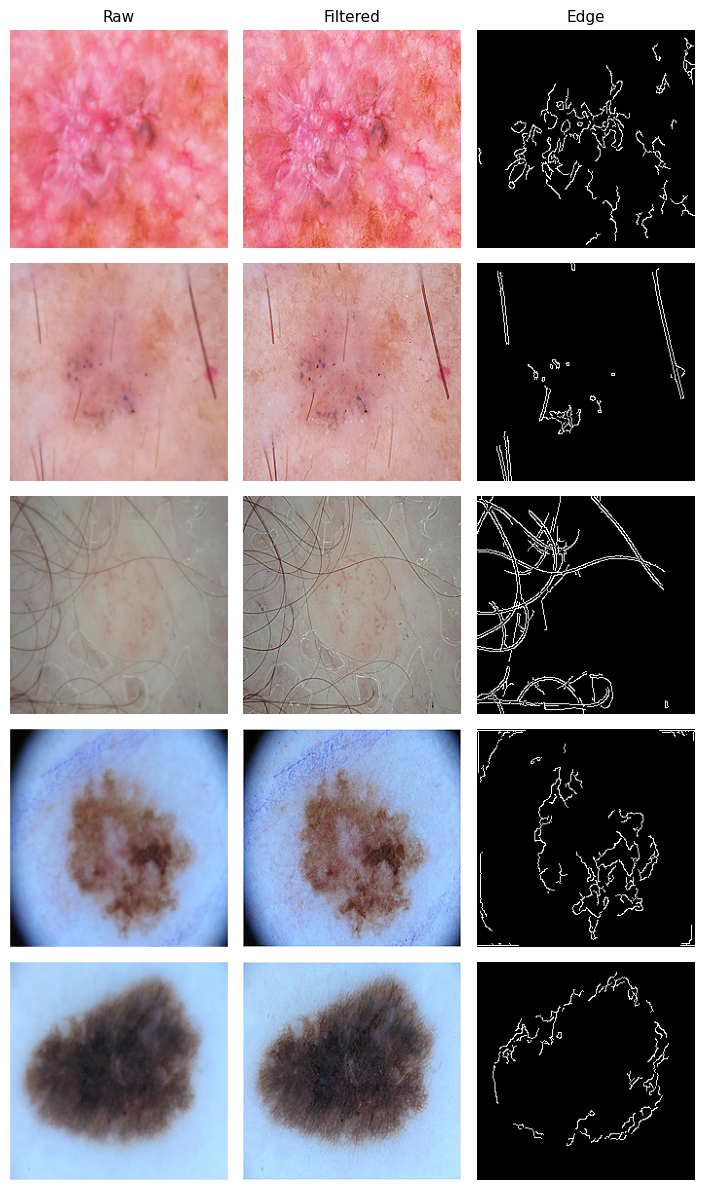

In [18]:
def _apply_sharpen(img_uint8):
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
    return cv2.filter2D(img_uint8, -1, kernel)

def apply_condition(img_uint8, condition_name):
    if condition_name == "raw":
        return img_uint8
    if condition_name == "filtered":
        assert BEST_FILTER == "sharpen", "only Sharpening is implemented as BEST_FILTER"
        return _apply_sharpen(img_uint8)
    if condition_name == "edge":
        edge_map = compute_edge_map(img_uint8, BEST_EDGE_METHOD, **BEST_EDGE_PARAMS)
        return cv2.cvtColor(edge_map, cv2.COLOR_GRAY2RGB)
    raise ValueError(condition_name)

class ConditionISICDataset(Dataset):
    def __init__(self, df, condition_name, transform=None):
        self.df = df.reset_index(drop=True)
        self.condition_name = condition_name
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        arr = apply_condition(IMAGE_CACHE[row["filepath"]], self.condition_name)
        img = Image.fromarray(arr)
        if self.transform:
            img = self.transform(img)
        return img, int(row["label_idx"])

train_transform = T.Compose([T.RandomHorizontalFlip(), T.RandomRotation(15), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
eval_transform = T.Compose([T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

def build_condition_loaders(condition_name):
    _persist = CONFIG["num_workers"] > 0
    train_ds = ConditionISICDataset(train_df, condition_name, train_transform)
    val_ds = ConditionISICDataset(val_df, condition_name, eval_transform)
    test_ds = ConditionISICDataset(test_df, condition_name, eval_transform)
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                               num_workers=CONFIG["num_workers"], pin_memory=True, persistent_workers=_persist)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                             num_workers=CONFIG["num_workers"], pin_memory=True, persistent_workers=_persist)
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                              num_workers=CONFIG["num_workers"], pin_memory=True, persistent_workers=_persist)
    return train_loader, val_loader, test_loader, test_ds

# Visualize one example image per class, across all 3 conditions.
fig, axes = plt.subplots(len(CLASSES), len(CONDITIONS), figsize=(2.4 * len(CONDITIONS), 2.4 * len(CLASSES)))
for i, cls in enumerate(CLASSES):
    arr = SAMPLE_IMAGES[cls]
    for j, cond in enumerate(CONDITIONS):
        axes[i, j].imshow(apply_condition(arr, cond)); axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(CONDITION_DISPLAY[cond], fontsize=11)
        if j == 0:
            axes[i, j].set_ylabel(cls, fontsize=11)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task4_condition_examples.png", dpi=120)
plt.show()


## 9. Task 4/5: Training Sweep

Runs all 5 rows (ResNet50, EfficientNet-B0, SVM, Random Forest, KNN) on all 3 conditions, 15 (row, condition) pairs total, checkpointing after each one so a disconnect only costs whatever was in flight. Re-running this cell after an interruption resumes rather than redoing completed work.

The 2 CNN models are fine-tuned end to end per condition, same as Lab 1/2. The 3 classical classifiers reuse that condition's just-fine-tuned ResNet50 (head swapped to `nn.Identity()`) as their deep-feature extractor, matching how Lab 1 built its classical-classifier features from the winning fine-tuned backbone rather than a generic frozen ImageNet one; ResNet50's weights are saved per condition specifically so this works even if the classifier cell runs in a later session than the training cell.


In [19]:
def run_cnn_condition(model_name, condition_name, completed, extras):
    disp, disp_cond = MODEL_DISPLAY[model_name], CONDITION_DISPLAY[condition_name]
    if (disp, disp_cond) in completed:
        print(f"Skipping {disp} / {disp_cond} (already completed)")
        return
    train_loader, val_loader, test_loader, test_ds = build_condition_loaders(condition_name)

    print(f"\n=== {disp}  |  condition={disp_cond} ===")
    t0 = time.time()
    model = build_model(model_name, NUM_CLASSES, freeze_backbone=True)
    model, history = train_warmup_finetune(model, train_loader, val_loader, CONFIG, class_weights_tensor, CONFIG["device"])
    summary, per_class, cm, y_true, y_prob = evaluate_full(model, test_loader, NUM_CLASSES, CONFIG["device"])
    elapsed = time.time() - t0

    sample_tensor = test_ds[0][0]
    x = sample_tensor.unsqueeze(0).to(CONFIG["device"])
    model.eval()
    def _one_forward_pass():
        with torch.no_grad():
            model(x)
    inf_ms = time_ms(_one_forward_pass)

    row = {"Row": disp, "Condition": disp_cond, **summary, "Training Time (s)": round(elapsed, 1), "Inference Time (ms)": round(inf_ms, 3)}
    print(f"{disp} / {disp_cond}: acc={summary['Accuracy (%)']:.2f}%  (took {elapsed/60:.1f} min)")

    payload = {"history": history, "confusion_matrix": cm, "per_class": per_class, "y_true": y_true, "y_prob": y_prob}
    save_condition(row, f"{model_name}__{condition_name}", extras, payload)
    completed.add((disp, disp_cond))

    if model_name == "resnet50":
        weights_path = f"{RESULTS_DIR}/resnet50_{condition_name}.pt"
        torch.save(model.state_dict(), weights_path)
        print("Saved ResNet50 weights to", weights_path, "(reused below for deep-feature extraction)")

    del model
    if CONFIG["device"] == "cuda":
        torch.cuda.empty_cache()

def get_resnet50_feature_extractor(condition_name):
    weights_path = f"{RESULTS_DIR}/resnet50_{condition_name}.pt"
    assert os.path.exists(weights_path), (
        f"ResNet50 weights for condition='{condition_name}' not found at {weights_path}. "
        f"Run run_cnn_condition('resnet50', '{condition_name}', ...) first.")
    model = build_model("resnet50", NUM_CLASSES, freeze_backbone=False)
    model.load_state_dict(torch.load(weights_path, map_location=CONFIG["device"]))
    model.fc = nn.Identity()
    return model.to(CONFIG["device"])

def extract_deep_features(feature_model, df, condition_name, device):
    feature_model.eval()
    ds = ConditionISICDataset(df, condition_name, eval_transform)
    loader = DataLoader(ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    feats, labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            f = feature_model(imgs.to(device)).cpu().numpy()
            feats.append(f); labels.append(lbls.numpy())
    return np.concatenate(feats), np.concatenate(labels)

def run_classifier_condition(clf_name, condition_name, completed, extras):
    disp, disp_cond = CLASSIFIER_DISPLAY[clf_name], CONDITION_DISPLAY[condition_name]
    if (disp, disp_cond) in completed:
        print(f"Skipping {disp} / {disp_cond} (already completed)")
        return

    feat_key = f"features__{condition_name}"
    feat_paths = {s: f"{RESULTS_DIR}/feat_{condition_name}_{s}.npy" for s in ["train_X", "train_y", "test_X", "test_y"]}
    if feat_key not in extras or not all(os.path.exists(p) for p in feat_paths.values()):
        feature_model = get_resnet50_feature_extractor(condition_name)
        t0 = time.time()
        X_train, y_train = extract_deep_features(feature_model, train_df, condition_name, CONFIG["device"])
        X_test, y_test = extract_deep_features(feature_model, test_df, condition_name, CONFIG["device"])
        extraction_time = time.time() - t0
        np.save(feat_paths["train_X"], X_train); np.save(feat_paths["train_y"], y_train)
        np.save(feat_paths["test_X"], X_test); np.save(feat_paths["test_y"], y_test)
        extras[feat_key] = {"extraction_time_s": extraction_time, "n_train": len(y_train), "n_test": len(y_test)}
        with open(EXTRAS_JSON, "w") as f:
            json.dump(extras, f)
        print(f"Extracted deep features for condition={condition_name} in {extraction_time/60:.1f} min "
              f"(shared across SVM/Random Forest/KNN, timed once)")
        del feature_model
        if CONFIG["device"] == "cuda":
            torch.cuda.empty_cache()
    else:
        X_train, y_train = np.load(feat_paths["train_X"]), np.load(feat_paths["train_y"])
        X_test, y_test = np.load(feat_paths["test_X"]), np.load(feat_paths["test_y"])

    print(f"\n=== {disp}  |  condition={disp_cond} ===")
    Xtr, ytr = X_train, y_train
    if clf_name == "svm" and len(Xtr) > SVM_SUBSAMPLE_SIZE:
        Xtr, _, ytr, _ = train_test_split(Xtr, ytr, train_size=SVM_SUBSAMPLE_SIZE, stratify=ytr, random_state=SEED)

    clf = CLASSIFIER_DEFS[clf_name]()
    t0 = time.time()
    clf.fit(Xtr, ytr)
    fit_time = time.time() - t0
    y_pred = clf.predict(X_test)

    acc = (y_pred == y_test).mean()
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    y_proba = None
    try:
        y_proba = clf.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro", labels=np.arange(NUM_CLASSES))
    except Exception:
        auc = float("nan")
    pc_p, pc_r, pc_f1, pc_support = precision_recall_fscore_support(y_test, y_pred, average=None, zero_division=0, labels=np.arange(NUM_CLASSES))
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(NUM_CLASSES))

    feature_model = get_resnet50_feature_extractor(condition_name)
    timing_ds = ConditionISICDataset(test_df.iloc[[0]], condition_name, eval_transform)
    x = timing_ds[0][0].unsqueeze(0).to(CONFIG["device"])
    feature_model.eval()
    def _one_call():
        with torch.no_grad():
            feat = feature_model(x).cpu().numpy()
        clf.predict(feat)
    inf_ms = time_ms(_one_call)
    del feature_model
    if CONFIG["device"] == "cuda":
        torch.cuda.empty_cache()

    summary = {
        "Accuracy (%)": acc * 100, "Precision (%)": precision * 100, "Recall (%)": recall * 100,
        "F1-score (%)": f1 * 100, "Macro-F1 (%)": f1 * 100, "Balanced Accuracy (%)": bal_acc * 100, "AUC (%)": auc * 100,
    }
    row = {"Row": disp, "Condition": disp_cond, **summary, "Training Time (s)": round(fit_time, 2), "Inference Time (ms)": round(inf_ms, 3)}
    print(f"{disp} / {disp_cond}: acc={acc*100:.2f}%  (fit took {fit_time:.1f}s)")

    payload = {
        "confusion_matrix": cm.tolist(),
        "per_class": {"precision": pc_p.tolist(), "recall": pc_r.tolist(), "f1": pc_f1.tolist(), "support": pc_support.tolist()},
        "y_true": y_test.tolist(), "y_prob": y_proba.tolist() if y_proba is not None else None,
    }
    save_condition(row, f"{clf_name}__{condition_name}", extras, payload)
    completed.add((disp, disp_cond))

def run_full_sweep():
    completed, extras = load_checkpoint()
    for condition_name in CONDITIONS:
        run_cnn_condition("resnet50", condition_name, completed, extras)
        run_cnn_condition("efficientnet_b0", condition_name, completed, extras)
        for clf_name in CLASSIFIERS:
            run_classifier_condition(clf_name, condition_name, completed, extras)
    print("\nAll 15 (row, condition) pairs attempted. If any were skipped due to an error, re-run this cell.")

run_full_sweep()



=== ResNet50  |  condition=Raw ===
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]


  [warmup] epoch 1/1  train_loss=1.2091  train_acc=0.5826  val_loss=1.0974  val_acc=0.6112
  [finetune] epoch 1/4  train_loss=0.8873  train_acc=0.6784  val_loss=0.8072  val_acc=0.7081
  [finetune] epoch 2/4  train_loss=0.6467  train_acc=0.7564  val_loss=0.7062  val_acc=0.7751
  [finetune] epoch 3/4  train_loss=0.4767  train_acc=0.8131  val_loss=0.7297  val_acc=0.7894
  [finetune] epoch 4/4  train_loss=0.3741  train_acc=0.8482  val_loss=0.6687  val_acc=0.7949
ResNet50 / Raw: acc=80.37%  (took 14.3 min)
Saved ResNet50 weights to /content/drive/MyDrive/Lab03_ISIC_EdgeDetection/resnet50_raw.pt (reused below for deep-feature extraction)

=== EfficientNet-B0  |  condition=Raw ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 124MB/s]


  [warmup] epoch 1/1  train_loss=1.2014  train_acc=0.5773  val_loss=1.1020  val_acc=0.5787
  [finetune] epoch 1/4  train_loss=0.9445  train_acc=0.6589  val_loss=0.8115  val_acc=0.6853
  [finetune] epoch 2/4  train_loss=0.7227  train_acc=0.7300  val_loss=0.7217  val_acc=0.7115
  [finetune] epoch 3/4  train_loss=0.6169  train_acc=0.7647  val_loss=0.6780  val_acc=0.7379
  [finetune] epoch 4/4  train_loss=0.4990  train_acc=0.7990  val_loss=0.6674  val_acc=0.7773
EfficientNet-B0 / Raw: acc=78.58%  (took 7.1 min)
Extracted deep features for condition=raw in 1.2 min (shared across SVM/Random Forest/KNN, timed once)

=== SVM  |  condition=Raw ===
SVM / Raw: acc=82.68%  (fit took 123.8s)

=== Random Forest  |  condition=Raw ===
Random Forest / Raw: acc=79.87%  (fit took 182.4s)

=== KNN  |  condition=Raw ===
KNN / Raw: acc=81.31%  (fit took 0.0s)

=== ResNet50  |  condition=Filtered ===
  [warmup] epoch 1/1  train_loss=1.2013  train_acc=0.5864  val_loss=1.0896  val_acc=0.6167
  [finetune] epoch

## 10. Task 5: Cross-Lab Classification Performance Comparison

`results3_df` is the complete 15-row table (every metric, all 3 conditions, all 5 rows), the primary output. `table3_df` is the brief's own narrower template shape (5 rows, Raw/Filtered/Edge as explicit accuracy columns, one shared Precision/Recall/F1/time set taken from the Edge condition since that is this lab's new contribution); see the title cell for why the fresh 3-condition numbers are used here rather than Lab 1/2's original numbers.


In [20]:
results3_df = pd.read_csv(RESULTS_CSV)
row_order = ["SVM", "Random Forest", "KNN", "ResNet50", "EfficientNet-B0"]
cond_order = [CONDITION_DISPLAY[c] for c in CONDITIONS]
results3_df["Row"] = pd.Categorical(results3_df["Row"], categories=row_order, ordered=True)
results3_df["Condition"] = pd.Categorical(results3_df["Condition"], categories=cond_order, ordered=True)
results3_df = results3_df.sort_values(["Row", "Condition"]).reset_index(drop=True)

expected_rows = len(row_order) * len(CONDITIONS)
print(f"{len(results3_df)}/{expected_rows} (row, condition) pairs completed.")
if len(results3_df) < expected_rows:
    print("Some conditions are still missing, re-run Task 4/5's sweep cell until this says "
          f"{expected_rows}/{expected_rows} before trusting the analysis below.")

cols = ["Row", "Condition", "Accuracy (%)", "Precision (%)", "Recall (%)", "F1-score (%)",
        "Macro-F1 (%)", "Balanced Accuracy (%)", "AUC (%)", "Training Time (s)", "Inference Time (ms)"]
results3_df = results3_df[cols].round(3)
results3_df.to_csv(f"{RESULTS_DIR}/table3_full_long_format.csv", index=False)
results3_df


15/15 (row, condition) pairs completed.


,Row,Condition,Accuracy (%),Precision (%),Recall (%),F1-score (%),Macro-F1 (%),Balanced Accuracy (%),AUC (%),Training Time (s),Inference Time (ms)
0,SVM,Raw,82.682,79.364,73.349,75.781,75.781,73.349,95.460,123.76,15.032
1,SVM,Filtered,82.709,78.657,74.219,76.060,76.060,74.219,95.396,121.49,14.191
2,SVM,Edge,62.445,49.874,37.775,39.056,39.056,37.775,78.804,245.32,20.702
3,Random Forest,Raw,79.873,78.528,66.293,70.477,70.477,66.293,94.895,182.41,63.856
4,Random Forest,Filtered,80.534,77.088,67.806,71.177,71.177,67.806,95.038,186.71,64.436
5,Random Forest,Edge,61.206,55.102,34.090,34.511,34.511,34.090,79.298,152.31,64.224
6,KNN,Raw,81.305,75.948,72.725,73.844,73.844,72.725,92.493,0.02,82.680
7,KNN,Filtered,81.635,75.609,74.370,74.286,74.286,74.370,92.958,0.01,71.974
8,KNN,Edge,59.003,43.752,41.841,42.359,42.359,41.841,73.582,0.02,83.635
9,ResNet50,Raw,80.369,71.352,76.710,73.348,73.348,76.710,95.088,860.50,5.675


In [21]:
# The brief's own narrower template shape, derived from results3_df above.
display_row_map = {"SVM": "SVM", "Random Forest": "Random Forest", "KNN": "KNN",
                    "CNN Model 1": "ResNet50", "CNN Model 2": "EfficientNet-B0"}
table3_rows = []
for template_name, real_name in display_row_map.items():
    sub = results3_df[results3_df["Row"] == real_name].set_index("Condition")
    edge = sub.loc["Edge"]
    table3_rows.append({
        "Model / Classifier": template_name,
        "Accuracy Raw (Lab 1)": sub.loc["Raw", "Accuracy (%)"],
        "Accuracy Filtered (Lab 2)": sub.loc["Filtered", "Accuracy (%)"],
        "Accuracy Edge (Lab 3)": edge["Accuracy (%)"],
        "Precision": edge["Precision (%)"], "Recall": edge["Recall (%)"], "F1-Score": edge["F1-score (%)"],
        "Training Time (s)": edge["Training Time (s)"], "Inference Time (ms)": edge["Inference Time (ms)"],
    })
table3_df = pd.DataFrame(table3_rows)
table3_df.to_csv(f"{RESULTS_DIR}/table3_brief_template.csv", index=False)
table3_df


,Model / Classifier,Accuracy Raw (Lab 1),Accuracy Filtered (Lab 2),Accuracy Edge (Lab 3),Precision,Recall,F1-Score,Training Time (s),Inference Time (ms)
0,SVM,82.682,82.709,62.445,49.874,37.775,39.056,245.32,20.702
1,Random Forest,79.873,80.534,61.206,55.102,34.090,34.511,152.31,64.224
2,KNN,81.305,81.635,59.003,43.752,41.841,42.359,0.02,83.635
3,CNN Model 1,80.369,80.176,53.524,41.899,45.334,42.294,863.80,6.488
4,CNN Model 2,78.579,78.276,50.000,41.124,46.217,40.203,437.80,9.732


## 11. Task 6: Visual Comparison of Classification Results

For the single best-performing (row, condition) pair, shows that row's confusion matrix on all 3 conditions side by side, plus a grouped bar chart of Accuracy/Precision/Recall/F1 across the 3 conditions for that row.


Best-performing (row, condition): SVM / Filtered (82.71% accuracy). Showing SVM's confusion matrices across all 3 conditions below.


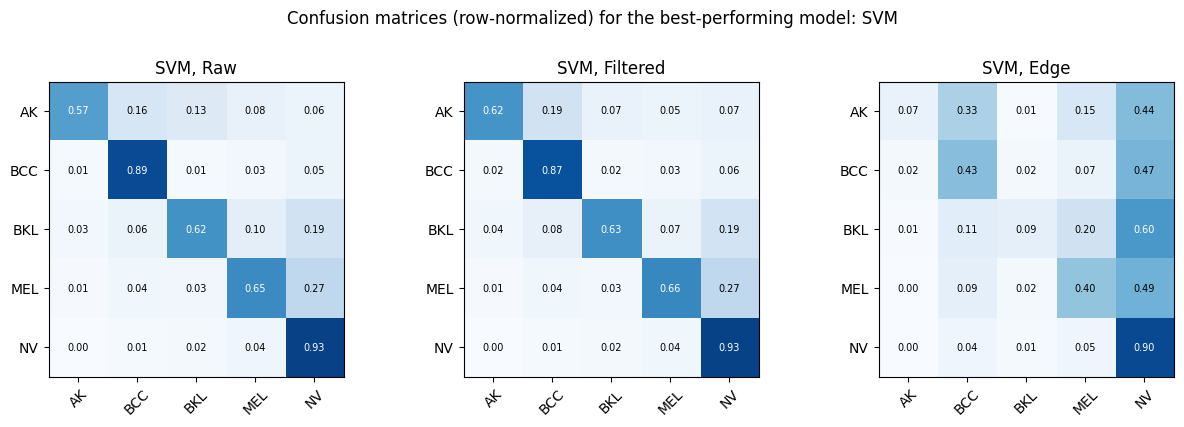

In [22]:
with open(EXTRAS_JSON) as f:
    extras = json.load(f)

ROW_INTERNAL_NAME = {"ResNet50": "resnet50", "EfficientNet-B0": "efficientnet_b0",
                      "SVM": "svm", "Random Forest": "random_forest", "KNN": "knn"}
CONDITION_INTERNAL_NAME = {v: k for k, v in CONDITION_DISPLAY.items()}

def get_extra(row_disp, condition_disp):
    key = f"{ROW_INTERNAL_NAME[row_disp]}__{CONDITION_INTERNAL_NAME[condition_disp]}"
    return extras.get(key)

_idx_best = results3_df["Accuracy (%)"].idxmax()
BEST_ROW = results3_df.loc[_idx_best, "Row"]
print(f"Best-performing (row, condition): {BEST_ROW} / {results3_df.loc[_idx_best, 'Condition']} "
      f"({results3_df.loc[_idx_best, 'Accuracy (%)']:.2f}% accuracy). "
      f"Showing {BEST_ROW}'s confusion matrices across all 3 conditions below.")

fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(4.2 * len(CONDITIONS), 4))
for ax, cond in zip(axes, [CONDITION_DISPLAY[c] for c in CONDITIONS]):
    e = get_extra(BEST_ROW, cond)
    cm = np.array(e["confusion_matrix"])
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45)
    ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
    ax.set_title(f"{BEST_ROW}, {cond}")
    for r in range(cm_norm.shape[0]):
        for c in range(cm_norm.shape[1]):
            ax.text(c, r, f"{cm_norm[r, c]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if cm_norm[r, c] > 0.5 else "black")
fig.suptitle(f"Confusion matrices (row-normalized) for the best-performing model: {BEST_ROW}", y=1.03)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task6_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()


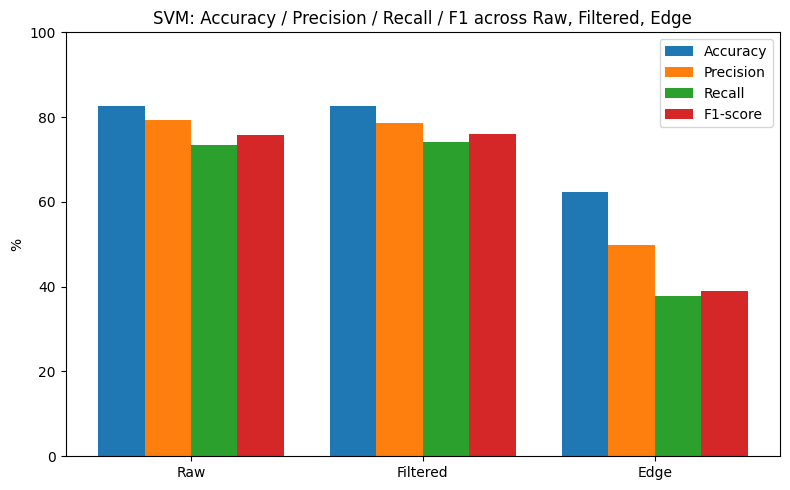

,Accuracy (%),Precision (%),Recall (%),F1-score (%)
Condition,,,,
Raw,82.682,79.364,73.349,75.781
Filtered,82.709,78.657,74.219,76.060
Edge,62.445,49.874,37.775,39.056


In [23]:
metrics_to_plot = ["Accuracy (%)", "Precision (%)", "Recall (%)", "F1-score (%)"]
sub = results3_df[results3_df["Row"] == BEST_ROW].set_index("Condition").reindex([CONDITION_DISPLAY[c] for c in CONDITIONS])

x = np.arange(len(CONDITIONS)); width = 0.2
fig, ax = plt.subplots(figsize=(8, 5))
for i, m in enumerate(metrics_to_plot):
    ax.bar(x + (i - 1.5) * width, sub[m].values, width, label=m.replace(" (%)", ""))
ax.set_xticks(x); ax.set_xticklabels(sub.index)
ax.set_ylabel("%"); ax.set_ylim(0, 100)
ax.set_title(f"{BEST_ROW}: Accuracy / Precision / Recall / F1 across Raw, Filtered, Edge")
ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task6_metric_comparison.png", dpi=120)
plt.show()
sub[metrics_to_plot]


**Does edge detection improve or reduce classification performance?** Fill this in once the sweep above has run: compare `sub.loc["Edge"]` against `sub.loc["Raw"]` and `sub.loc["Filtered"]` for `BEST_ROW`, and check whether the same direction holds for the other 4 rows in `results3_df`. Worth cross-referencing against Lab 2's own finding that Sobel (used there as a preprocessing filter, not unlike what Set C does here) cost every model 9 to 12 points of accuracy by discarding color and texture entirely, if `BEST_EDGE_METHOD` above turned out to be Sobel or another gradient-based method, a similar drop here would be consistent with that, whereas Canny's thinner, more selective edge map may be less destructive.


## 12. Comparative Analysis

A few more real, computed numbers that the report's Discussion section and the Discussion Questions below will draw on.


In [24]:
# Accuracy delta: Filtered and Edge, each versus that row's own Raw baseline.
raw_baseline = results3_df[results3_df["Condition"] == "Raw"].set_index("Row")
delta_rows = []
for _, r in results3_df[results3_df["Condition"] != "Raw"].iterrows():
    base = raw_baseline.loc[r["Row"]]
    delta_rows.append({
        "Row": r["Row"], "Condition": r["Condition"],
        "Delta Accuracy (%)": round(r["Accuracy (%)"] - base["Accuracy (%)"], 2),
        "Delta Macro-F1 (%)": round(r["Macro-F1 (%)"] - base["Macro-F1 (%)"], 2),
        "Delta Balanced Accuracy (%)": round(r["Balanced Accuracy (%)"] - base["Balanced Accuracy (%)"], 2),
    })
delta_vs_raw_df = pd.DataFrame(delta_rows)
delta_vs_raw_df.to_csv(f"{RESULTS_DIR}/deltas_vs_raw.csv", index=False)
print("Change vs. each row's own Raw baseline (positive = Edge/Filtered did better than Raw):")
delta_vs_raw_df


Change vs. each row's own Raw baseline (positive = Edge/Filtered did better than Raw):


,Row,Condition,Delta Accuracy (%),Delta Macro-F1 (%),Delta Balanced Accuracy (%)
0,SVM,Filtered,0.03,0.28,0.87
1,SVM,Edge,-20.24,-36.73,-35.57
2,Random Forest,Filtered,0.66,0.70,1.51
3,Random Forest,Edge,-18.67,-35.97,-32.20
4,KNN,Filtered,0.33,0.44,1.65
5,KNN,Edge,-22.30,-31.48,-30.88
6,ResNet50,Filtered,-0.19,0.97,0.71
7,ResNet50,Edge,-26.84,-31.05,-31.38
8,EfficientNet-B0,Filtered,-0.30,1.22,1.47
9,EfficientNet-B0,Edge,-28.58,-30.20,-29.49


In [25]:
# Per-class F1, long format, one row per (row, condition, class): which classes are most
# affected by moving from Raw to Edge specifically.
per_class_rows = []
for row_name in row_order:
    for cond in [CONDITION_DISPLAY[c] for c in CONDITIONS]:
        e = get_extra(row_name, cond)
        if e is None:
            continue
        pc = e["per_class"]
        for c, cls in enumerate(CLASSES):
            per_class_rows.append({"Row": row_name, "Condition": cond, "Class": cls,
                                    "F1 (%)": round(pc["f1"][c] * 100, 2), "Support": pc["support"][c]})
per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(f"{RESULTS_DIR}/per_class_results.csv", index=False)

edge_vs_raw_by_class = (per_class_df[per_class_df["Condition"] == "Edge"].groupby("Class")["F1 (%)"].mean()
                         - per_class_df[per_class_df["Condition"] == "Raw"].groupby("Class")["F1 (%)"].mean())
edge_vs_raw_by_class = edge_vs_raw_by_class.reindex(CLASSES).sort_values()
print("Mean F1 change, Edge vs. Raw, averaged across all 5 rows, per class (most hurt first):")
print(edge_vs_raw_by_class.round(2))


Mean F1 change, Edge vs. Raw, averaged across all 5 rows, per class (most hurt first):
Class
BKL   -45.83
AK    -41.80
BCC   -38.97
MEL   -22.94
NV    -15.89
Name: F1 (%), dtype: float64


## 13. Discussion Questions and Viva Questions (reference)

These are answered properly, with the real numbers above, in the README/report once this notebook has been run end to end. Kept here so they are easy to check against while reviewing results in Colab.

**Discussion Questions (answer these in the report):**

1. Edge Detection and Noise: which edge detector was most sensitive to noise? Use Table 1's `Noise Sensitivity` column.
2. Effect of Filtering: how did Gaussian and Median filtering affect the quality of detected edges? Compare the relevant Table 1 rows.
3. Canny Parameters: how did changing the low/high thresholds affect the number and quality of detected edges? Use Table 2.
4. Edge Maps and Classification: did edge-only images improve or reduce classification accuracy versus raw images, and why? Use `results3_df` (Edge vs. Raw) and `delta_vs_raw_df`.
5. Information Loss: edge maps mainly represent boundaries, what information (texture, color, intensity) is lost?
6. Classical vs. Deep Features: CNNs learn edge-like features automatically, what is the advantage of that over manually supplying edge maps?
7. Best Representation: based on Labs 01 to 03, which representation (raw, filtered, edge) produced the most useful classification results? Use `results3_df` across all 3 conditions.

**Viva Questions (conceptual, prepare answers but these are not written up in the report):**

What is an edge in an image? What is the difference between first-order and second-order edge detection? What is the difference between Sobel (Gx) and (Gy)? Why is the Laplacian more sensitive to noise? What is the purpose of Gaussian smoothing before edge detection? What is the main advantage of Canny edge detection? What are Canny's low and high thresholds? What is the difference between Gaussian and Salt-and-Pepper noise? Why is Median filtering useful for Salt-and-Pepper noise? Why can edge detection reduce classification performance? Can a CNN learn edge features automatically? Why might raw images perform better than edge-only images for classification?


## 14. Summary

| Variable / file | Contains |
|---|---|
| `table1_df` | Task 2's noise/preprocessing effect table (11 rows), also `table1_noise_effect.csv` |
| `table2_df` | Task 3's Canny parameter analysis (4 rows), also `table2_canny_params.csv` |
| `BEST_EDGE_METHOD` | the automatically-selected edge method used for Set C |
| `results3_df` | the full 15-row Task 4/5 comparison (every metric x 3 conditions x 5 rows), also `table3_full_long_format.csv` |
| `table3_df` | the brief's own Table 3 template shape, also `table3_brief_template.csv` |
| `delta_vs_raw_df`, `per_class_df` | comparative-analysis support, also saved as CSVs |
| `extras` | full per-condition history + confusion matrices + per-class data, also `extras.json` |
| `RESULTS_DIR` | all of the above, plus every figure saved along the way and the per-condition ResNet50 weights |

Once `results3_df` shows 15/15 completed, send back the executed `.ipynb` (or just the CSVs and figures from `RESULTS_DIR`, if that is easier to attach) and the GitHub README for Lab 03 will be written from these real numbers, answering the brief's Discussion Questions.
